In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
import os
import unicodedata
import re
import difflib
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import statsmodels.formula.api as smf
import scipy.stats as stats

from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

file_path = "/Users/macbook/Downloads/data.xlsx"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Expected data file not found at {file_path}")

# Load Excel (try first sheet)
df = pd.read_excel(file_path)
print("File loaded. Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())


File loaded. Shape: (37, 29)
Columns:
['Giới tính', 'Bạn là sinh viên năm mấy? ', 'Bạn có biết đến thương hiệu Highlands Coffee không?', 'Bạn có thường uống cà phê/trà sữa tại Highlands Coffee không?', 'Tần suất bạn uống cà phê 1 tuần', 'Khi nhắc đến Highlands Coffee, bạn nghĩ đến điều gì đầu tiên? (có thể chọn nhiều phương án)', 'Trong những yếu tố trên, bạn nghĩ yếu tố nào là quan trọng nhất? Vì sao?', 'Vậy đối với kiosk Highlands ở UEL, bạn sẽ đến với mục đích gì?', 'Bạn chi bao nhiêu cho 1 thức uống ở Highlands', 'Tôi tin rằng sản phẩm của Highland Coffee có chất lượng tốt', 'Không gian tại các cửa hàng Highland Coffee rất thoải mái và phù hợp để học tập, làm việc', 'Tôi đánh giá cao chất lượng dịch vụ của Highland Coffee', 'Tôi đánh giá cao về thái độ phục vụ và chăm sóc khách hàng của nhân viên tại Highland Coffee', 'Tôi thấy giá cả của Highland Coffee phù hợp với sinh viên', 'Nếu Highlands Coffee mở một cửa hàng dạng kiosk ngay tại khuôn viên trường Đại học Kinh tế - Luật (UEL),

# ĐƠN BIẾN

In [106]:
print("=" * 20)
print("CÂU HỎI NGHIÊN CỨU 1:")
print("Mức độ ảnh hưởng của nhận thức chất lượng sản phẩm đến ý định ủng hộ mở kiosk")
print("=" * 20)

# Chuẩn bị dữ liệu cho câu hỏi 1
# Biến phụ thuộc: Ý định ủng hộ mở kiosk (cột O)
# Biến độc lập: Nhận thức chất lượng sản phẩm (cột I)

# Lấy tên cột thực tế từ dòng đầu tiên (index 0)
quality_col = df.columns[8]  # Cột I - Chất lượng sản phẩm
support_col = df.columns[14] # Cột O - Ý định ủng hộ

print(f"Biến độc lập: {quality_col}")
print(f"Biến phụ thuộc: {support_col}")

# Tạo DataFrame cho phân tích hồi quy
regression_data = df.iloc[1:].copy()  # Bỏ dòng tiêu đề

# Chuyển đổi kiểu dữ liệu
regression_data[quality_col] = pd.to_numeric(regression_data[quality_col], errors='coerce')
regression_data[support_col] = pd.to_numeric(regression_data[support_col], errors='coerce')

# Loại bỏ các giá trị NaN
regression_data = regression_data.dropna(subset=[quality_col, support_col])

# Đổi tên cột cho dễ sử dụng
X = regression_data[quality_col]
y = regression_data[support_col]

print(f"\nKích thước mẫu: {len(regression_data)}")
print(f"\nThống kê mô tả:")
print(f"Chất lượng sản phẩm - Mean: {X.mean():.2f}, Std: {X.std():.2f}")
print(f"Ý định ủng hộ - Mean: {y.mean():.2f}, Std: {y.std():.2f}")


CÂU HỎI NGHIÊN CỨU 1:
Mức độ ảnh hưởng của nhận thức chất lượng sản phẩm đến ý định ủng hộ mở kiosk
Biến độc lập: Bạn chi bao nhiêu cho 1 thức uống ở Highlands
Biến phụ thuộc: Nếu Highlands Coffee mở một cửa hàng dạng kiosk ngay tại khuôn viên trường Đại học Kinh tế - Luật (UEL), bạn có sẵn sàng ủng hộ không?

Kích thước mẫu: 36

Thống kê mô tả:
Chất lượng sản phẩm - Mean: 52888.89, Std: 6877.61
Ý định ủng hộ - Mean: 3.92, Std: 0.97


In [107]:
# =============================================================================
# 1. PHÂN TÍCH HỒI QUY OLS
# =============================================================================

print("\n" + "="*20)
print("PHÂN TÍCH HỒI QUY OLS")
print("="*20)

# Thêm hằng số cho mô hình OLS
X_with_const = sm.add_constant(X)

# Thực hiện hồi quy OLS
model = sm.OLS(y, X_with_const).fit()

# Hiển thị kết quả hồi quy
print(model.summary())


PHÂN TÍCH HỒI QUY OLS
                                                                                      OLS Regression Results                                                                                      
Dep. Variable:     Nếu Highlands Coffee mở một cửa hàng dạng kiosk ngay tại khuôn viên trường Đại học Kinh tế - Luật (UEL), bạn có sẵn sàng ủng hộ không?   R-squared:                       0.095
Model:                                                                                                                                                OLS   Adj. R-squared:                  0.068
Method:                                                                                                                                     Least Squares   F-statistic:                     3.558
Date:                                                                                                                                    Mon, 27 Oct 2025   Prob (F-statistic):             0.0678
Ti

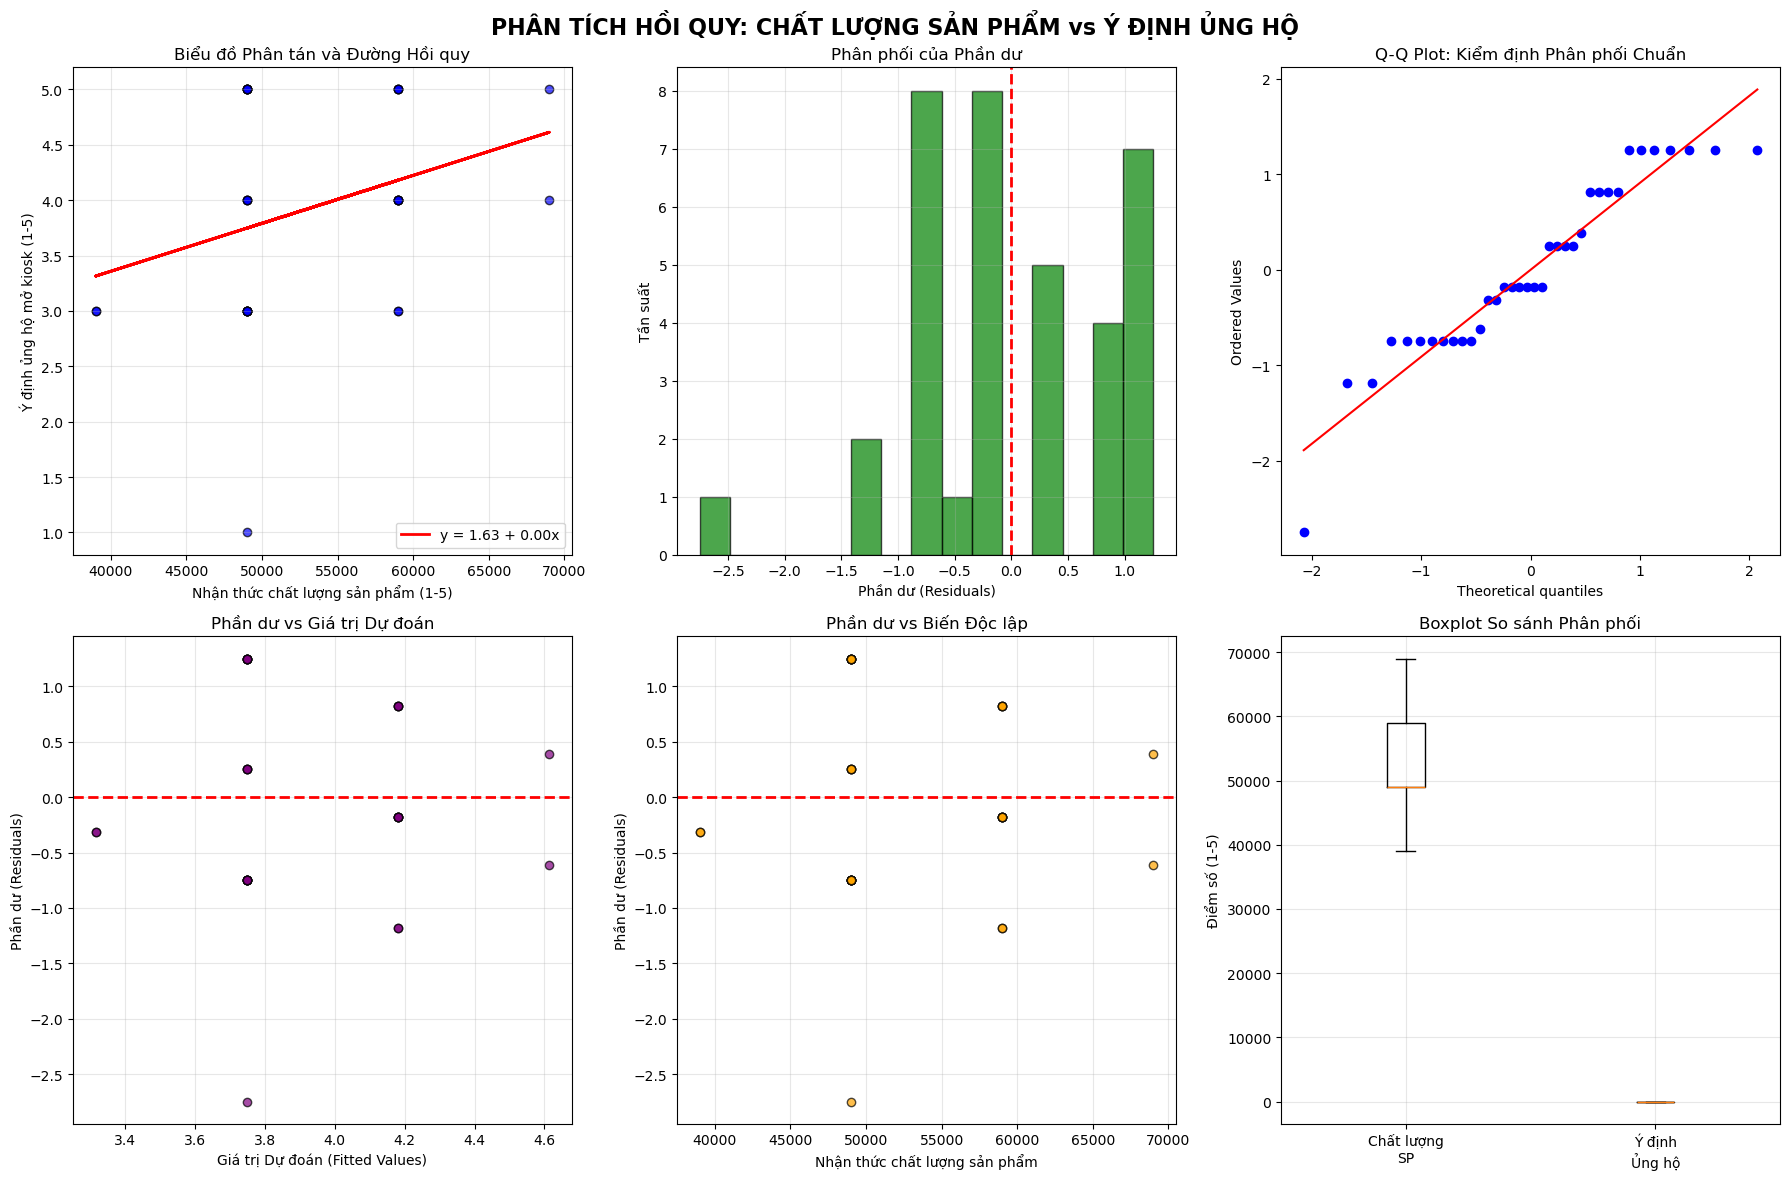

In [108]:
# =============================================================================
# 2. TRỰC QUAN HÓA DỮ LIỆU
# =============================================================================

# Tạo subplot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('PHÂN TÍCH HỒI QUY: CHẤT LƯỢNG SẢN PHẨM vs Ý ĐỊNH ỦNG HỘ', fontsize=16, fontweight='bold')

# Biểu đồ 1: Scatter plot với đường hồi quy
axes[0, 0].scatter(X, y, alpha=0.7, color='blue', edgecolors='black')
axes[0, 0].plot(X, model.predict(X_with_const), color='red', linewidth=2, label=f'y = {model.params[0]:.2f} + {model.params[1]:.2f}x')
axes[0, 0].set_xlabel('Nhận thức chất lượng sản phẩm (1-5)')
axes[0, 0].set_ylabel('Ý định ủng hộ mở kiosk (1-5)')
axes[0, 0].set_title('Biểu đồ Phân tán và Đường Hồi quy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Biểu đồ 2: Histogram của phần dư
residuals = model.resid
axes[0, 1].hist(residuals, bins=15, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Phần dư (Residuals)')
axes[0, 1].set_ylabel('Tần suất')
axes[0, 1].set_title('Phân phối của Phần dư')
axes[0, 1].grid(True, alpha=0.3)

# Biểu đồ 3: Q-Q plot cho kiểm định tính chuẩn
stats.probplot(residuals, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Q-Q Plot: Kiểm định Phân phối Chuẩn')

# Biểu đồ 4: Residuals vs Fitted values
fitted_values = model.fittedvalues
axes[1, 0].scatter(fitted_values, residuals, alpha=0.7, color='purple', edgecolors='black')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Giá trị Dự đoán (Fitted Values)')
axes[1, 0].set_ylabel('Phần dư (Residuals)')
axes[1, 0].set_title('Phần dư vs Giá trị Dự đoán')
axes[1, 0].grid(True, alpha=0.3)

# Biểu đồ 5: Residuals vs Independent variable
axes[1, 1].scatter(X, residuals, alpha=0.7, color='orange', edgecolors='black')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Nhận thức chất lượng sản phẩm')
axes[1, 1].set_ylabel('Phần dư (Residuals)')
axes[1, 1].set_title('Phần dư vs Biến Độc lập')
axes[1, 1].grid(True, alpha=0.3)

# Biểu đồ 6: Boxplot so sánh phân phối
boxplot_data = [X, y]
axes[1, 2].boxplot(boxplot_data, labels=['Chất lượng\nSP', 'Ý định\nỦng hộ'])
axes[1, 2].set_title('Boxplot So sánh Phân phối')
axes[1, 2].set_ylabel('Điểm số (1-5)')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [109]:
# =============================================================================
# 3. KIỂM ĐỊNH CÁC GIẢ ĐỊNH HỒI QUY
# =============================================================================

print("\n" + "="*70)
print("KIỂM ĐỊNH CÁC GIẢ ĐỊNH HỒI QUY TUYẾN TÍNH")
print("="*70)

# Giả định 1: Mối quan hệ tuyến tính
correlation = X.corr(y)
print(f"1. MỐI QUAN HỆ TUYẾN TÍNH:")
print(f"   - Hệ số tương quan Pearson: {correlation:.4f}")
print(f"   - p-value tương quan: {stats.pearsonr(X, y)[1]:.4f}")

# Giả định 2: Phương sai sai số không đổi (Homoscedasticity)
print(f"\n2. PHƯƠNG SAI SAI SỐ KHÔNG ĐỔI (Homoscedasticity):")
# Kiểm định Breusch-Pagan
bp_test = het_breuschpagan(residuals, X_with_const)
print(f"   - Kiểm định Breusch-Pagan:")
print(f"     LM Statistic: {bp_test[0]:.4f}")
print(f"     p-value: {bp_test[1]:.4f}")
print(f"     F-statistic: {bp_test[2]:.4f}")
print(f"     F p-value: {bp_test[3]:.4f}")

if bp_test[1] > 0.05:
    print("   => KHÔNG có bằng chứng về phương sai thay đổi (Homoscedasticity)")
else:
    print("   => CÓ bằng chứng về phương sai thay đổi (Heteroscedasticity)")

# Giả định 3: Không có tự tương quan (Autocorrelation)
print(f"\n3. KHÔNG CÓ TỰ TƯƠNG QUAN:")
durbin_watson = sm.stats.stattools.durbin_watson(residuals)
print(f"   - Thống kê Durbin-Watson: {durbin_watson:.4f}")

if durbin_watson < 1.5:
    print("   => CÓ tự tương quan dương")
elif durbin_watson > 2.5:
    print("   => CÓ tự tương quan âm")
else:
    print("   => KHÔNG có tự tương quan đáng kể")

# Giả định 4: Phần dư có phân phối chuẩn
print(f"\n4. PHÂN PHỐI CHUẨN CỦA PHẦN DƯ:")
# Kiểm định Shapiro-Wilk
shapiro_test = stats.shapiro(residuals)
print(f"   - Kiểm định Shapiro-Wilk:")
print(f"     W-statistic: {shapiro_test[0]:.4f}")
print(f"     p-value: {shapiro_test[1]:.4f}")

# Kiểm định Kolmogorov-Smirnov
ks_test = stats.kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))
print(f"   - Kiểm định Kolmogorov-Smirnov:")
print(f"     KS-statistic: {ks_test[0]:.4f}")
print(f"     p-value: {ks_test[1]:.4f}")

if shapiro_test[1] > 0.05:
    print("   => Phần dư có phân phối CHUẨN (Shapiro-Wilk)")
else:
    print("   => Phần dư KHÔNG có phân phối chuẩn (Shapiro-Wilk)")



KIỂM ĐỊNH CÁC GIẢ ĐỊNH HỒI QUY TUYẾN TÍNH
1. MỐI QUAN HỆ TUYẾN TÍNH:
   - Hệ số tương quan Pearson: 0.3078
   - p-value tương quan: 0.0678

2. PHƯƠNG SAI SAI SỐ KHÔNG ĐỔI (Homoscedasticity):
   - Kiểm định Breusch-Pagan:
     LM Statistic: 0.9364
     p-value: 0.3332
     F-statistic: 0.9080
     F p-value: 0.3474
   => KHÔNG có bằng chứng về phương sai thay đổi (Homoscedasticity)

3. KHÔNG CÓ TỰ TƯƠNG QUAN:
   - Thống kê Durbin-Watson: 1.1309
   => CÓ tự tương quan dương

4. PHÂN PHỐI CHUẨN CỦA PHẦN DƯ:
   - Kiểm định Shapiro-Wilk:
     W-statistic: 0.9143
     p-value: 0.0086
   - Kiểm định Kolmogorov-Smirnov:
     KS-statistic: 0.1336
     p-value: 0.4996
   => Phần dư KHÔNG có phân phối chuẩn (Shapiro-Wilk)


In [110]:
# =============================================================================
# 4. PHÂN TÍCH BỔ SUNG
# =============================================================================

print("\n" + "="*70)
print("PHÂN TÍCH BỔ SUNG VÀ DIỄN GIẢI KẾT QUẢ")
print("="*70)

# Đánh giá mức độ ảnh hưởng
r_squared = model.rsquared
adj_r_squared = model.rsquared_adj

print(f"1. ĐỘ PHÙ HỢP CỦA MÔ HÌNH:")
print(f"   - R-squared: {r_squared:.4f} ({r_squared*100:.2f}%)")
print(f"   - Adjusted R-squared: {adj_r_squared:.4f} ({adj_r_squared*100:.2f}%)")

# Diễn giải hệ số hồi quy
intercept = model.params[0]
slope = model.params[1]
slope_pvalue = model.pvalues[1]

print(f"\n2. HỆ SỐ HỒI QUY:")
print(f"   - Hệ số chặn (Intercept): {intercept:.4f}")
print(f"   - Hệ số góc (Slope): {slope:.4f}")
print(f"   - p-value của hệ số góc: {slope_pvalue:.4f}")

# Đánh giá ý nghĩa thống kê
if slope_pvalue < 0.05:
    significance = "CÓ Ý NGHĨA THỐNG KÊ"
else:
    significance = "KHÔNG CÓ Ý NGHĨA THỐNG KÊ"

print(f"\n3. KẾT LUẬN:")
print(f"   - Mối quan hệ: {significance}")
print(f"   - Khi nhận thức chất lượng tăng 1 điểm, ý định ủng hộ thay đổi: {slope:.4f} điểm")

# Dự đoán ví dụ
if slope_pvalue < 0.05:
    print(f"   - Ví dụ: Nếu chất lượng từ 3 điểm → 4 điểm (+1), ý định ủng hộ tăng: {slope:.2f} điểm")
    print(f"   - Dự đoán ý định ủng hộ khi chất lượng = 5: {intercept + slope*5:.2f} điểm")

# Đánh giá hiệu ứng thực tế
effect_size = "NHỎ" if abs(slope) < 0.3 else "TRUNG BÌNH" if abs(slope) < 0.6 else "LỚN"
print(f"   - Quy mô hiệu ứng: {effect_size}")

print(f"\n4. KHUYẾN NGHỊ:")
if slope_pvalue < 0.05 and slope > 0:
    print("   → TẬP TRUNG NÂNG CAO CHẤT LƯỢNG SẢN PHẨM để tăng ý định ủng hộ")
elif slope_pvalue >= 0.05:
    print("   → CẦN XEM XÉT CÁC YẾU TỐ KHÁC ảnh hưởng đến ý định ủng hộ")
else:
    print("   → PHÂN TÍCH THÊM các yếu tố tác động")




PHÂN TÍCH BỔ SUNG VÀ DIỄN GIẢI KẾT QUẢ
1. ĐỘ PHÙ HỢP CỦA MÔ HÌNH:
   - R-squared: 0.0947 (9.47%)
   - Adjusted R-squared: 0.0681 (6.81%)

2. HỆ SỐ HỒI QUY:
   - Hệ số chặn (Intercept): 1.6272
   - Hệ số góc (Slope): 0.0000
   - p-value của hệ số góc: 0.0678

3. KẾT LUẬN:
   - Mối quan hệ: KHÔNG CÓ Ý NGHĨA THỐNG KÊ
   - Khi nhận thức chất lượng tăng 1 điểm, ý định ủng hộ thay đổi: 0.0000 điểm
   - Quy mô hiệu ứng: NHỎ

4. KHUYẾN NGHỊ:
   → CẦN XEM XÉT CÁC YẾU TỐ KHÁC ảnh hưởng đến ý định ủng hộ


In [111]:
# =============================================================================
# 5. PHÂN TÍCH ĐỘ NHẠY
# =============================================================================

print("\n" + "="*70)
print("PHÂN TÍCH ĐỘ NHẠY")
print("="*70)

# Phân tích theo nhóm điểm chất lượng
quality_groups = pd.cut(X, bins=[0, 2, 3, 4, 5], labels=['Thấp (1-2)', 'Trung bình (3)', 'Khá (4)', 'Cao (5)'])
group_analysis = pd.DataFrame({
    'Chất lượng': quality_groups,
    'Ủng hộ': y
}).groupby('Chất lượng').agg(['mean', 'count', 'std']).round(3)

print("Phân tích theo nhóm chất lượng:")
print(group_analysis)

# Phân tích outliers
Q1 = residuals.quantile(0.25)
Q3 = residuals.quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = 1.5 * IQR
outliers = residuals[(residuals < (Q1 - outlier_threshold)) | (residuals > (Q3 + outlier_threshold))]
print(f"\nSố lượng outliers trong phần dư: {len(outliers)}")

print("\n" + "="*70)
print("KẾT THÚC PHÂN TÍCH CÂU HỎI 1")
print("="*70)


PHÂN TÍCH ĐỘ NHẠY
Phân tích theo nhóm chất lượng:
               Ủng hộ          
                 mean count std
Chất lượng                     
Thấp (1-2)        NaN     0 NaN
Trung bình (3)    NaN     0 NaN
Khá (4)           NaN     0 NaN
Cao (5)           NaN     0 NaN

Số lượng outliers trong phần dư: 0

KẾT THÚC PHÂN TÍCH CÂU HỎI 1


# ĐA BIẾN

PHÂN TÍCH HỒI QUY ĐA BIẾN - CÂU HỎI NGHIÊN CỨU 2

📊 THÔNG TIN DỮ LIỆU:
Số lượng quan sát: 37
Số lượng biến: 29

Số lượng quan sát sau khi xử lý missing values: 37

📈 THỐNG KÊ MÔ TẢ CÁC BIẾN:
       Y_dinh_ung_ho  Chat_luong_san_pham  Khong_gian  Chat_luong_dich_vu  \
count      37.000000            37.000000   37.000000           37.000000   
mean        3.945946             4.243243    3.945946            3.945946   
std         0.970279             0.796011    0.911225            0.779813   
min         1.000000             1.000000    2.000000            2.000000   
25%         3.000000             4.000000    3.000000            3.000000   
50%         4.000000             4.000000    4.000000            4.000000   
75%         5.000000             5.000000    5.000000            4.000000   
max         5.000000             5.000000    5.000000            5.000000   

       Thai_do_phuc_vu     Gia_ca  
count        37.000000  37.000000  
mean          3.945946   3.216216  
std    

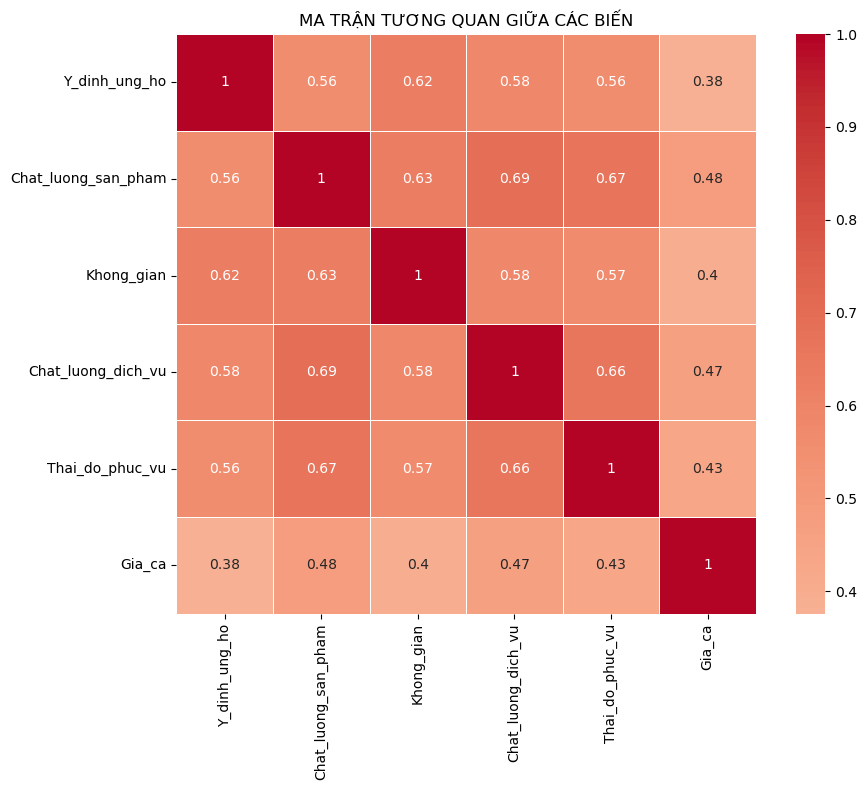

In [112]:
# Hiển thị thông tin cơ bản về dữ liệu
print("=" * 70)
print("PHÂN TÍCH HỒI QUY ĐA BIẾN - CÂU HỎI NGHIÊN CỨU 2")
print("=" * 70)

print("\n📊 THÔNG TIN DỮ LIỆU:")
print(f"Số lượng quan sát: {len(df)}")
print(f"Số lượng biến: {len(df.columns)}")

# Chuẩn bị dữ liệu cho hồi quy
# Biến phụ thuộc: Ý định ủng hộ mở kiosk (cột O)
# Biến độc lập: Các yếu tố dịch vụ (cột I, J, K, L, M)

# Đổi tên cột cho dễ làm việc
column_mapping = {
    'Nếu Highlands Coffee mở một cửa hàng dạng kiosk ngay tại khuôn viên trường Đại học Kinh tế - Luật (UEL), bạn có sẵn sàng ủng hộ không?': 'Y_dinh_ung_ho',
    'Tôi tin rằng sản phẩm của Highland Coffee có chất lượng tốt': 'Chat_luong_san_pham',
    'Không gian tại các cửa hàng Highland Coffee rất thoải mái và phù hợp để học tập, làm việc': 'Khong_gian',
    'Tôi đánh giá cao chất lượng dịch vụ của Highland Coffee': 'Chat_luong_dich_vu',
    'Tôi đánh giá cao về thái độ phục vụ và chăm sóc khách hàng của nhân viên tại Highland Coffee': 'Thai_do_phuc_vu',
    'Tôi thấy giá cả của Highland Coffee phù hợp với sinh viên': 'Gia_ca'
}

df_renamed = df.rename(columns=column_mapping)

# Lựa chọn các biến cần thiết
variables = ['Y_dinh_ung_ho', 'Chat_luong_san_pham', 'Khong_gian', 
             'Chat_luong_dich_vu', 'Thai_do_phuc_vu', 'Gia_ca']

df_regression = df_renamed[variables].copy()

# Loại bỏ các dòng có giá trị thiếu
df_regression = df_regression.dropna()

print(f"\nSố lượng quan sát sau khi xử lý missing values: {len(df_regression)}")

# Thống kê mô tả
print("\n📈 THỐNG KÊ MÔ TẢ CÁC BIẾN:")
print(df_regression.describe())

# Ma trận tương quan
print("\n🔗 MA TRẬN TƯƠNG QUAN:")
correlation_matrix = df_regression.corr()
print(correlation_matrix.round(3))

# Trực quan hóa ma trận tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('MA TRẬN TƯƠNG QUAN GIỮA CÁC BIẾN')
plt.tight_layout()
plt.show()



In [113]:
# Phân tích hồi quy OLS
import statsmodels.api as sm

# Chuẩn bị biến
X = df_regression[['Chat_luong_san_pham', 'Khong_gian', 'Chat_luong_dich_vu', 
                   'Thai_do_phuc_vu', 'Gia_ca']]
y = df_regression['Y_dinh_ung_ho']

# Thêm hằng số
X = sm.add_constant(X)

# Chạy mô hình hồi quy
model = sm.OLS(y, X).fit()

print("\n" + "="*80)
print("KẾT QUẢ HỒI QUY OLS")
print("="*80)
print(model.summary())

# Phân tích hệ số chi tiết
print("\n📊 PHÂN TÍCH HỆ SỐ HỒI QUY:")
coefficients = model.params
p_values = model.pvalues

for i, (coef, pval) in enumerate(zip(coefficients, p_values)):
    if i == 0:
        print(f"Hằng số (const): {coef:.4f} (p-value: {pval:.4f})")
    else:
        var_name = X.columns[i]
        significance = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else " (không có ý nghĩa)"
        print(f"{var_name}: {coef:.4f} (p-value: {pval:.4f}){significance}")



KẾT QUẢ HỒI QUY OLS
                            OLS Regression Results                            
Dep. Variable:          Y_dinh_ung_ho   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     5.840
Date:                Mon, 27 Oct 2025   Prob (F-statistic):           0.000652
Time:                        15:39:07   Log-Likelihood:                -38.600
No. Observations:                  37   AIC:                             89.20
Df Residuals:                      31   BIC:                             98.86
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const        

=== THÔNG TIN DỮ LIỆU ===
Kích thước dữ liệu: (37, 29)

Tên các cột:
0: Giới tính
1: Bạn là sinh viên năm mấy? 
2: Bạn có biết đến thương hiệu Highlands Coffee không?
3: Bạn có thường uống cà phê/trà sữa tại Highlands Coffee không?
4: Tần suất bạn uống cà phê 1 tuần
5: Khi nhắc đến Highlands Coffee, bạn nghĩ đến điều gì đầu tiên? (có thể chọn nhiều phương án)
6: Trong những yếu tố trên, bạn nghĩ yếu tố nào là quan trọng nhất? Vì sao?
7: Vậy đối với kiosk Highlands ở UEL, bạn sẽ đến với mục đích gì?
8: Bạn chi bao nhiêu cho 1 thức uống ở Highlands
9: Tôi tin rằng sản phẩm của Highland Coffee có chất lượng tốt
10: Không gian tại các cửa hàng Highland Coffee rất thoải mái và phù hợp để học tập, làm việc
11: Tôi đánh giá cao chất lượng dịch vụ của Highland Coffee
12: Tôi đánh giá cao về thái độ phục vụ và chăm sóc khách hàng của nhân viên tại Highland Coffee
13: Tôi thấy giá cả của Highland Coffee phù hợp với sinh viên
14: Nếu Highlands Coffee mở một cửa hàng dạng kiosk ngay tại khuôn viên

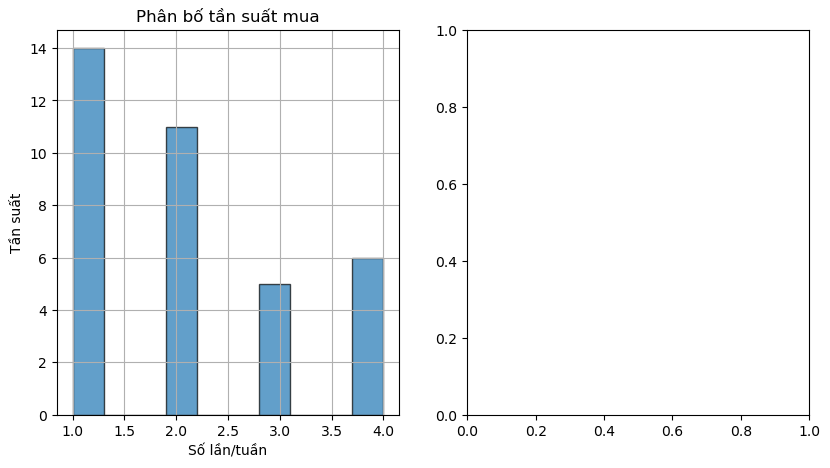

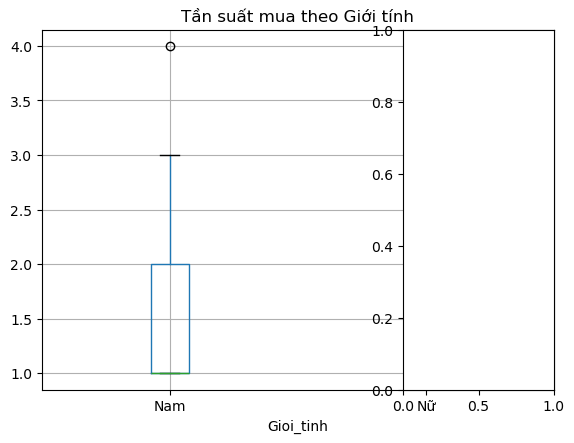

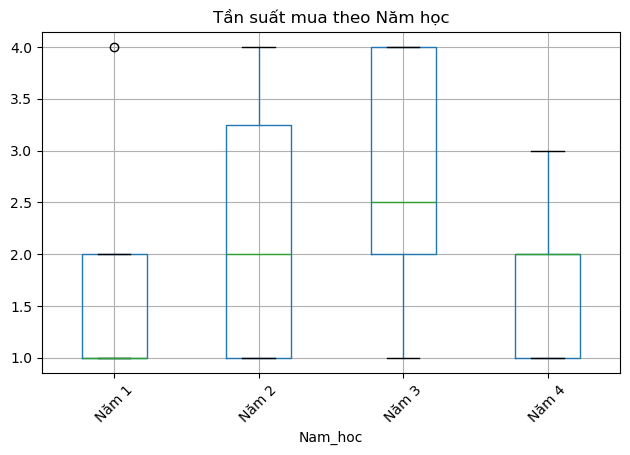


HỒI QUY ĐƠN BIẾN: ẢNH HƯỞNG CỦA GIỚI TÍNH
                            OLS Regression Results                            
Dep. Variable:            Tan_suat_so   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     2.669
Date:                Mon, 27 Oct 2025   Prob (F-statistic):              0.112
Time:                        15:39:07   Log-Likelihood:                -52.815
No. Observations:                  36   AIC:                             109.6
Df Residuals:                      34   BIC:                             112.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [114]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
import scipy.stats as stats

# Đọc dữ liệu từ file Excel
# Hiển thị thông tin cơ bản về dữ liệu
print("=== THÔNG TIN DỮ LIỆU ===")
print(f"Kích thước dữ liệu: {df.shape}")
print("\nTên các cột:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

print("\n5 dòng đầu của dữ liệu:")
print(df.head())

# Xác định đúng tên cột từ dữ liệu
print("\n=== XÁC ĐỊNH CỘT DỮ LIỆU ===")
gender_col = df.columns[0]  # Cột giới tính
year_col = df.columns[1]    # Cột năm học
frequency_col = df.columns[15]  # Cột tần suất mua dự kiến

print(f"Cột giới tính: {gender_col}")
print(f"Cột năm học: {year_col}")
print(f"Cột tần suất: {frequency_col}")

# Tạo dataframe cho phân tích
analysis_df = pd.DataFrame()
analysis_df['Gioi_tinh'] = df[gender_col]
analysis_df['Nam_hoc'] = df[year_col]
analysis_df['Tan_suat_du_kien'] = df[frequency_col]

print(f"\nSố lượng dữ liệu ban đầu: {len(analysis_df)}")
print("\nGiá trị duy nhất trong cột tần suất mua dự kiến:")
print(analysis_df['Tan_suat_du_kien'].value_counts())

# Tiền xử lý dữ liệu
def preprocess_frequency(x):
    if pd.isna(x):
        return np.nan
    x_str = str(x)
    if '1 lần' in x_str:
        return 1
    elif '2 lần' in x_str:
        return 2
    elif '3 lần' in x_str:
        return 3
    elif '4 lần' in x_str:
        return 4
    elif 'Chưa biết' in x_str or 'chưa biết' in x_str:
        return np.nan
    else:
        return np.nan

# Áp dụng tiền xử lý tần suất
analysis_df['Tan_suat_so'] = analysis_df['Tan_suat_du_kien'].apply(preprocess_frequency)

# Tạo biến giả
analysis_df['Gioi_tinh_dummy'] = analysis_df['Gioi_tinh'].apply(lambda x: 1 if x == 'Nữ' else 0)

# Tạo biến giả cho năm học
year_dummies = pd.get_dummies(analysis_df['Nam_hoc'], prefix='Nam')
analysis_df = pd.concat([analysis_df, year_dummies], axis=1)

# Loại bỏ các dòng có giá trị thiếu
df_clean = analysis_df.dropna(subset=['Tan_suat_so']).copy()

print(f"\nSố lượng dữ liệu sau khi làm sạch: {len(df_clean)}")
print(f"Tỷ lệ giữ lại: {len(df_clean)/len(analysis_df)*100:.1f}%")

print("\nThống kê mô tả tần suất mua dự kiến:")
print(df_clean['Tan_suat_so'].describe())

# Phân tích tần suất theo giới tính và năm học
print("\n=== PHÂN TÍCH TẦN SUẤT THEO GIỚI TÍNH ===")
gender_stats = df_clean.groupby('Gioi_tinh')['Tan_suat_so'].describe()
print(gender_stats)

print("\n=== PHÂN TÍCH TẦN SUẤT THEO NĂM HỌC ===")
year_stats = df_clean.groupby('Nam_hoc')['Tan_suat_so'].describe()
print(year_stats)

# Vẽ biểu đồ phân bố
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df_clean['Tan_suat_so'].hist(bins=10, alpha=0.7, edgecolor='black')
plt.title('Phân bố tần suất mua')
plt.xlabel('Số lần/tuần')
plt.ylabel('Tần suất')

plt.subplot(1, 3, 2)
df_clean.boxplot(column='Tan_suat_so', by='Gioi_tinh')
plt.title('Tần suất mua theo Giới tính')
plt.suptitle('')

plt.subplot(1, 3, 3)
df_clean.boxplot(column='Tan_suat_so', by='Nam_hoc')
plt.title('Tần suất mua theo Năm học')
plt.suptitle('')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# HỒI QUY ĐƠN BIẾN - GIỚI TÍNH
print("\n" + "="*80)
print("HỒI QUY ĐƠN BIẾN: ẢNH HƯỞNG CỦA GIỚI TÍNH")
print("="*80)

X_single = sm.add_constant(df_clean['Gioi_tinh_dummy'])
y = df_clean['Tan_suat_so']

model_single = sm.OLS(y, X_single)
results_single = model_single.fit()

print(results_single.summary())



In [115]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')



# Hiển thị thông tin cơ bản về dữ liệu
print("=== THÔNG TIN DỮ LIỆU ===")
print(f"Kích thước dữ liệu: {df.shape}")
print("\nKiểu dữ liệu của các cột:")
print(df.dtypes)

# Xác định đúng các cột cần thiết
print("\n=== XÁC ĐỊNH CÁC CỘT DỮ LIỆU ===")

# Tìm cột giới tính (có thể là cột đầu tiên)
gender_col = df.columns[0]
print(f"Cột giới tính: {gender_col}")

# Tìm cột năm học
year_col = df.columns[1]
print(f"Cột năm học: {year_col}")

# Tìm cột tần suất mua dự kiến - tìm cột có chứa "lần/tuần"
frequency_col = None
for col in df.columns:
    if any(keyword in str(col) for keyword in ['lần/tuần', 'lần', 'tuần', 'P']):
        frequency_col = col
        break
if frequency_col is None:
    frequency_col = df.columns[15]  # Fallback to column 15

print(f"Cột tần suất: {frequency_col}")

# Tạo dataframe cho phân tích với kiểu dữ liệu phù hợp
analysis_df = pd.DataFrame()
analysis_df['Gioi_tinh'] = df[gender_col].astype(str)
analysis_df['Nam_hoc'] = df[year_col].astype(str)
analysis_df['Tan_suat_du_kien'] = df[frequency_col].astype(str)

print(f"\nSố lượng dữ liệu ban đầu: {len(analysis_df)}")
print("\nGiá trị duy nhất trong cột tần suất mua dự kiến:")
print(analysis_df['Tan_suat_du_kien'].value_counts())

# Tiền xử lý dữ liệu
def preprocess_frequency(x):
    if pd.isna(x) or x == 'nan' or x == 'None':
        return np.nan
    x_str = str(x).strip()
    if '1 lần' in x_str:
        return 1
    elif '2 lần' in x_str:
        return 2
    elif '3 lần' in x_str:
        return 3
    elif '4 lần' in x_str:
        return 4
    elif 'Chưa biết' in x_str or 'chưa biết' in x_str:
        return np.nan
    else:
        # Thử chuyển đổi trực tiếp nếu là số
        try:
            return float(x_str)
        except:
            return np.nan

# Áp dụng tiền xử lý tần suất
analysis_df['Tan_suat_so'] = analysis_df['Tan_suat_du_kien'].apply(preprocess_frequency)

# Tạo biến giả với kiểu số
analysis_df['Gioi_tinh_dummy'] = analysis_df['Gioi_tinh'].apply(
    lambda x: 1 if str(x).strip() == 'Nữ' else 0 if str(x).strip() == 'Nam' else np.nan
)

# Tạo biến giả cho năm học
year_dummies = pd.get_dummies(analysis_df['Nam_hoc'].astype(str), prefix='Nam')
analysis_df = pd.concat([analysis_df, year_dummies], axis=1)

# Loại bỏ các dòng có giá trị thiếu
df_clean = analysis_df.dropna(subset=['Tan_suat_so', 'Gioi_tinh_dummy']).copy()

# Chuyển đổi tất cả các cột số về kiểu float để tránh cảnh báo
numeric_columns = ['Tan_suat_so', 'Gioi_tinh_dummy'] + [col for col in df_clean.columns if col.startswith('Nam_')]
for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print(f"\nSố lượng dữ liệu sau khi làm sạch: {len(df_clean)}")
print(f"Tỷ lệ giữ lại: {len(df_clean)/len(analysis_df)*100:.1f}%")

print("\nThống kê mô tả tần suất mua dự kiến:")
print(df_clean['Tan_suat_so'].describe())

# Phân tích tần suất theo giới tính và năm học
print("\n=== PHÂN TÍCH TẦN SUẤT THEO GIỚI TÍNH ===")
gender_stats = df_clean.groupby('Gioi_tinh')['Tan_suat_so'].describe()
print(gender_stats)

print("\n=== PHÂN TÍCH TẦN SUẤT THEO NĂM HỌC ===")
year_stats = df_clean.groupby('Nam_hoc')['Tan_suat_so'].describe()
print(year_stats)

# Vẽ biểu đồ phân bố
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df_clean['Tan_suat_so'].hist(bins=10, alpha=0.7, edgecolor='black')
plt.title('Phân bố tần suất mua')
plt.xlabel('Số lần/tuần')
plt.ylabel('Tần suất')

plt.subplot(1, 3, 2)
df_clean.boxplot(column='Tan_suat_so', by='Gioi_tinh')
plt.title('Tần suất mua theo Giới tính')
plt.suptitle('')

plt.subplot(1, 3, 3)
df_clean.boxplot(column='Tan_suat_so', by='Nam_hoc')
plt.title('Tần suất mua theo Năm học')
plt.suptitle('')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# HỒI QUY ĐƠN BIẾN - GIỚI TÍNH
print("\n" + "="*80)
print("HỒI QUY ĐƠN BIẾN: ẢNH HƯỞNG CỦA GIỚI TÍNH")
print("="*80)

# Đảm bảo dữ liệu là numeric
X_single_data = pd.to_numeric(df_clean['Gioi_tinh_dummy'], errors='coerce').dropna()
y_single = pd.to_numeric(df_clean['Tan_suat_so'], errors='coerce').dropna()

# Căn chỉnh index
common_index = X_single_data.index.intersection(y_single.index)
X_single_data = X_single_data.loc[common_index]
y_single = y_single.loc[common_index]

X_single = sm.add_constant(X_single_data)

model_single = sm.OLS(y_single, X_single)
results_single = model_single.fit()

print(results_single.summary())

# HỒI QUY ĐA BIẾN - GIỚI TÍNH VÀ NĂM HỌC
print("\n" + "="*80)
print("HỒI QUY ĐA BIẾN: GIỚI TÍNH VÀ NĂM HỌC")
print("="*80)

# Kiểm tra xem các cột năm học có tồn tại không
year_cols = [col for col in df_clean.columns if col.startswith('Nam_')]
print("Các biến năm học có sẵn:")
print(year_cols)

# Chọn các biến độc lập
independent_vars = ['Gioi_tinh_dummy']
for year in ['2', '3', '4']:
    col_name = f'Nam_Năm {year}'
    if col_name in year_cols:
        independent_vars.append(col_name)

print(f"Biến độc lập sử dụng: {independent_vars}")

# Chuẩn bị dữ liệu cho hồi quy đa biến
X_multi_data = df_clean[independent_vars].copy()
y_multi = df_clean['Tan_suat_so'].copy()

# Đảm bảo tất cả dữ liệu là numeric
for col in X_multi_data.columns:
    X_multi_data[col] = pd.to_numeric(X_multi_data[col], errors='coerce')
y_multi = pd.to_numeric(y_multi, errors='coerce')

# Loại bỏ các hàng có giá trị NaN
valid_idx = X_multi_data.notna().all(axis=1) & y_multi.notna()
X_multi_clean = X_multi_data[valid_idx]
y_multi_clean = y_multi[valid_idx]

print(f"Số lượng dữ liệu cho hồi quy đa biến: {len(X_multi_clean)}")

X_multi = sm.add_constant(X_multi_clean)
model_multi = sm.OLS(y_multi_clean, X_multi)
results_multi = model_multi.fit()

print(results_multi.summary())

# KIỂM TRA ĐA CỘNG TUYẾN
print("\n=== KIỂM TRA ĐA CỘNG TUYẾN (VIF) ===")
vif_data = pd.DataFrame()
vif_data["Biến"] = X_multi.columns
try:
    vif_data["VIF"] = [variance_inflation_factor(X_multi.values, i) for i in range(X_multi.shape[1])]
    print(vif_data)
except Exception as e:
    print(f"Không thể tính VIF: {e}")

# KIỂM TRA 4 GIẢ ĐỊNH CỦA HỒI QUY TUYẾN TÍNH
print("\n" + "="*80)
print("KIỂM TRA 4 GIẢ ĐỊNH HỒI QUY TUYẾN TÍNH")
print("="*80)

# Lấy phần dư và giá trị dự đoán
residuals = results_multi.resid
fitted_values = results_multi.fittedvalues

# 1. Kiểm tra tính tuyến tính
print("1. KIỂM ĐỊNH TÍNH TUYẾN TÍNH")
print("   Phân tích đồ thị phần dư vs giá trị dự đoán")

# 2. Kiểm tra phương sai sai số không đổi
print("\n2. KIỂM ĐỊNH PHƯƠNG SAI SAI SỐ KHÔNG ĐỔI")
try:
    bp_test = het_breuschpagan(residuals, X_multi)
    print(f"   Breusch-Pagan test: LM={bp_test[0]:.4f}, p-value={bp_test[1]:.4f}")
    print(f"   => {'Phương sai không đổi' if bp_test[1] > 0.05 else 'Có hiện tượng phương sai thay đổi'}")
except Exception as e:
    print(f"   Không thể thực hiện kiểm định Breusch-Pagan: {e}")

# 3. Kiểm tra tính độc lập của phần dư (không có tự tương quan)
print("\n3. KIỂM ĐỊNH TỰ TƯƠNG QUAN")
try:
    dw_test = durbin_watson(residuals)
    print(f"   Durbin-Watson test: {dw_test:.4f}")
    print(f"   => {'Không có tự tương quan' if 1.5 < dw_test < 2.5 else 'Có thể có tự tương quan'}")
except Exception as e:
    print(f"   Không thể thực hiện kiểm định Durbin-Watson: {e}")

# 4. Kiểm tra tính phân phối chuẩn của phần dư
print("\n4. KIỂM ĐỊNH PHÂN PHỐI CHUẨN CỦA PHẦN DƯ")
try:
    if len(residuals) > 3 and len(residuals) < 5000:
        shapiro_test = shapiro(residuals)
        print(f"   Shapiro-Wilk test: W={shapiro_test[0]:.4f}, p-value={shapiro_test[1]:.4f}")
        print(f"   => {'Phần dư phân phối chuẩn' if shapiro_test[1] > 0.05 else 'Phần dư không phân phối chuẩn'}")
    else:
        print("   Không đủ điều kiện để thực hiện kiểm định Shapiro-Wilk")
except Exception as e:
    print(f"   Không thể thực hiện kiểm định Shapiro-Wilk: {e}")

# VẼ BIỂU ĐỒ KIỂM ĐỊNH GIẢ ĐỊNH
try:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Biểu đồ 1: Phần dư vs Giá trị dự đoán
    axes[0, 0].scatter(fitted_values, residuals, alpha=0.6, color='blue')
    axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Giá trị dự đoán', fontsize=12)
    axes[0, 0].set_ylabel('Phần dư', fontsize=12)
    axes[0, 0].set_title('Phần dư vs Giá trị dự đoán\n(Kiểm tra tính tuyến tính & phương sai)', fontsize=14)
    axes[0, 0].grid(True, alpha=0.3)

    # Biểu đồ 2: Q-Q plot
    if len(residuals) > 0:
        stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Q-Q Plot\n(Kiểm tra phân phối chuẩn)', fontsize=14)
    axes[0, 1].grid(True, alpha=0.3)

    # Biểu đồ 3: Histogram phần dư
    axes[1, 0].hist(residuals, bins=15, alpha=0.7, edgecolor='black', color='green')
    axes[1, 0].set_xlabel('Phần dư', fontsize=12)
    axes[1, 0].set_ylabel('Tần suất', fontsize=12)
    axes[1, 0].set_title('Phân phối phần dư', fontsize=14)
    axes[1, 0].grid(True, alpha=0.3)

    # Biểu đồ 4: Tần suất mua dự kiến theo giới tính và năm học
    if len(df_clean) > 0:
        df_clean['Gioi_tinh_Nam_hoc'] = df_clean['Gioi_tinh'] + '_' + df_clean['Nam_hoc']
        boxplot_data = [df_clean[df_clean['Gioi_tinh_Nam_hoc'] == group]['Tan_suat_so'] 
                        for group in df_clean['Gioi_tinh_Nam_hoc'].unique()[:8]]  # Giới hạn số nhóm
        axes[1, 1].boxplot(boxplot_data, labels=df_clean['Gioi_tinh_Nam_hoc'].unique()[:8])
        axes[1, 1].set_title('Tần suất mua theo Giới tính & Năm học', fontsize=14)
        axes[1, 1].set_xlabel('(Giới tính, Năm học)', fontsize=12)
        axes[1, 1].set_ylabel('Tần suất mua/tuần', fontsize=12)
        plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Không thể vẽ biểu đồ: {e}")

# PHÂN TÍCH KẾT QUẢ VÀ KẾT LUẬN
print("\n" + "="*80)
print("PHÂN TÍCH KẾT QUẢ VÀ KẾT LUẬN")
print("="*80)

print("📊 KẾT QUẢ HỒI QUY ĐA BIẾN:")
print(f"- R-squared: {results_multi.rsquared:.4f} ({results_multi.rsquared*100:.2f}%)")
print(f"- Adj R-squared: {results_multi.rsquared_adj:.4f}")
print(f"- F-statistic: {results_multi.fvalue:.4f}")
print(f"- Prob (F-statistic): {results_multi.f_pvalue:.4f}")

print("\n📈 HỆ SỐ HỒI QUY VÀ Ý NGHĨA THỐNG KÊ:")
coefficients = results_multi.params
p_values = results_multi.pvalues

for coef_name in coefficients.index:
    coef_value = coefficients[coef_name]
    p_value = p_values[coef_name]
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else " (không có ý nghĩa)"
    print(f"  {coef_name}: {coef_value:.4f}{significance} (p-value: {p_value:.4f})")

print("\n🎯 DIỄN GIẢI KẾT QUẢ:")

# Phân tích hệ số chặn (constant)
if 'const' in coefficients:
    print(f"- Giá trị cơ sở (constant): {coefficients['const']:.3f}")
    print("  Đây là tần suất mua dự kiến trung bình của sinh viên Nam năm 1")

# Phân tích ảnh hưởng của giới tính
if 'Gioi_tinh_dummy' in coefficients:
    coef_gender = coefficients['Gioi_tinh_dummy']
    p_gender = p_values['Gioi_tinh_dummy']
    
    if p_gender < 0.05:
        direction = "cao hơn" if coef_gender > 0 else "thấp hơn"
        print(f"- GIỚI TÍNH: Có ảnh hưởng có ý nghĩa thống kê (p = {p_gender:.4f})")
        print(f"  Sinh viên Nữ có tần suất mua {direction} {abs(coef_gender):.2f} lần/tuần so với Nam")
    else:
        print(f"- GIỚI TÍNH: Không có ảnh hưởng có ý nghĩa thống kê (p = {p_gender:.4f})")

# Phân tích ảnh hưởng của năm học
print("\n- SO SÁNH THEO NĂM HỌC (so với Năm 1):")
year_effects = {
    'Nam_Năm 2': 'Năm 2',
    'Nam_Năm 3': 'Năm 3', 
    'Nam_Năm 4': 'Năm 4'
}

for var, label in year_effects.items():
    if var in coefficients:
        coef_year = coefficients[var]
        p_year = p_values[var]
        
        if p_year < 0.05:
            direction = "cao hơn" if coef_year > 0 else "thấp hơn"
            print(f"  {label}: Có ý nghĩa thống kê (p = {p_year:.4f})")
            print(f"    Tần suất mua {direction} {abs(coef_year):.2f} lần/tuần so với Năm 1")
        else:
            print(f"  {label}: Không có ý nghĩa thống kê (p = {p_year:.4f})")

print("\n📋 ĐÁNH GIÁ MÔ HÌNH:")
if results_multi.f_pvalue < 0.05:
    print("  ✅ Mô hình có ý nghĩa thống kê (p < 0.05)")
else:
    print("  ❌ Mô hình không có ý nghĩa thống kê")

print(f"  📈 Mô hình giải thích được {results_multi.rsquared*100:.1f}% phương sai của tần suất mua")

print("\n🔍 KIỂM ĐỊNH GIẢ ĐỊNH:")
try:
    bp_pvalue = bp_test[1] if 'bp_test' in locals() else 1
    print(f"  - Phương sai không đổi: {'✅ Đạt' if bp_pvalue > 0.05 else '❌ Không đạt'}")
except:
    print(f"  - Phương sai không đổi: Không thể kiểm định")

try:
    dw_value = dw_test if 'dw_test' in locals() else 0
    print(f"  - Không tự tương quan: {'✅ Đạt' if 1.5 < dw_value < 2.5 else '❌ Không đạt'}")
except:
    print(f"  - Không tự tương quan: Không thể kiểm định")

try:
    shapiro_pvalue = shapiro_test[1] if 'shapiro_test' in locals() else 0.05
    print(f"  - Phân phối chuẩn: {'✅ Đạt' if shapiro_pvalue > 0.05 else '❌ Không đạt'}")
except:
    print(f"  - Phân phối chuẩn: Không thể kiểm định")

print("\n" + "="*80)
print("KHUYẾN NGHỊ CHO HIGHLANDS COFFEE")
print("="*80)

# Đưa ra khuyến nghị dựa trên kết quả phân tích
print("1. 🎯 CHIẾN LƯỢC NHÓM ĐỐI TƯỢNG:")
if 'Gioi_tinh_dummy' in coefficients and p_values['Gioi_tinh_dummy'] < 0.05:
    if coefficients['Gioi_tinh_dummy'] > 0:
        print("   - Tập trung vào sinh viên NỮ (có tần suất mua cao hơn)")
    else:
        print("   - Tập trung vào sinh viên NAM (có tần suất mua cao hơn)")
else:
    print("   - Giới tính không ảnh hưởng đáng kể, nên tiếp cận cả hai giới")

print("\n2. 🎓 CHIẾN LƯỢC THEO NĂM HỌC:")
significant_years = []
for var, label in year_effects.items():
    if var in p_values and p_values[var] < 0.05 and coefficients[var] > 0:
        significant_years.append(label)

if significant_years:
    print(f"   - Tập trung vào sinh viên năm: {', '.join(significant_years)}")
else:
    print("   - Năm học không ảnh hưởng đáng kể, nên tiếp cận đều các năm")

print("\n3. 📊 ĐÁNH GIÁ HIỆU QUẢ:")
if results_multi.rsquared > 0.3:
    print("   - Mô hình giải thích tốt cho tần suất mua hàng")
elif results_multi.rsquared > 0.1:
    print("   - Mô hình giải thích ở mức trung bình")
else:
    print("   - Mô hình giải thích hạn chế, cần xem xét thêm các yếu tố khác")

print("\n4. 🚀 HÀNH ĐỘNG CỤ THỂ:")
print("   - Thiết kế chương trình khuyến mãi phù hợp với nhóm đối tượng mục tiêu")
print("   - Phát triển sản phẩm đáp ứng nhu cầu cụ thể của từng nhóm")
print("   - Tối ưu hóa vị trí và thời gian hoạt động của kiosk")
print("   - Thu thập thêm dữ liệu để cải thiện độ chính xác của mô hình")

print("\n" + "="*80)
print("KẾT LUẬN")
print("="*80)
print("Phân tích hồi quy đa biến cho thấy mối quan hệ giữa giới tính, năm học với tần suất mua hàng dự kiến.")
print("Kết quả này cung cấp cơ sở khoa học cho việc ra quyết định chiến lược của Highlands Coffee")
print("khi mở kiosk tại UEL.")

=== THÔNG TIN DỮ LIỆU ===
Kích thước dữ liệu: (37, 29)

Kiểu dữ liệu của các cột:
Giới tính                                                                                                                                 object
Bạn là sinh viên năm mấy?                                                                                                                 object
Bạn có biết đến thương hiệu Highlands Coffee không?                                                                                       object
Bạn có thường uống cà phê/trà sữa tại Highlands Coffee không?                                                                             object
Tần suất bạn uống cà phê 1 tuần                                                                                                           object
Khi nhắc đến Highlands Coffee, bạn nghĩ đến điều gì đầu tiên? (có thể chọn nhiều phương án)                                               object
Trong những yếu tố trên, bạn nghĩ yếu tố nào là 

ValueError: index must be a MultiIndex to unstack, <class 'pandas.core.indexes.base.Index'> was passed